```text
✅ 1. Project Setup & Imports
✅ 2. Load Config & LLM
✅ 3. Understand Conditional Workflows
✅ 4. Create Router Node
✅ 5. Test Router Node
✅ 6. Create Math Node
✅ 7. Test Math Node
✅ 8. Create Research Node
✅ 9. Test Research Node
✅ 10. Create StateGraph
✅ 11. Add Nodes
✅ 12. Create Routing Function
✅ 13. Add Conditional Edges
✅ 14. Compile Graph
✅ 15. Test Math Query
✅ 16. Test Research Query
✅ 17. Visualize Workflow
✅ 18. Understand Routing
✅ 19. Final Recap
```

In [1]:
# ==========================================
# Notebook 4: Conditional Workflows
# Project Setup & Imports
# ==========================================

import os
import sys
import warnings

warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath("..")

if PROJECT_ROOT not in sys.path:
    sys.path.append(PROJECT_ROOT)

print("Project Root Added Successfully")
print(PROJECT_ROOT)

Project Root Added Successfully
c:\Users\Personal\Downloads\Learnyard-MLOps\GenAI-For-Dev-Course\19-LangGraph-Crash-Course


In [2]:
# ==========================================
# Load Config, LLM & LangGraph Components
# ==========================================

from src.utils.config_loader import load_config
from src.utils.model_loader import load_llm

from langgraph.graph import StateGraph
from langgraph.graph import START
from langgraph.graph import END

from src.states.state_schema import GraphState

config = load_config()
llm = load_llm()

print("Configuration Loaded Successfully")
print("LLM Loaded Successfully")
print(type(llm))

Configuration Loaded Successfully
LLM Loaded Successfully
<class 'langchain_openai.chat_models.base.ChatOpenAI'>


In [3]:
# ==========================================
# Understanding Conditional Workflows
# ==========================================

conditional_workflow = """
                START
                   |
                   v

              Router Node

              /        \\

             /          \\

            v            v

       Math Node    Research Node

             \\          /

              \\        /

                  END
"""

print(conditional_workflow)


                START
                   |
                   v

              Router Node

              /        \

             /          \

            v            v

       Math Node    Research Node

             \          /

              \        /

                  END



In [4]:
# ==========================================
# Router Node
# ==========================================

def router_node(state: GraphState):
    print("\n--- Router Node Executed ---")
    query = state["user_query"].lower()
    math_keywords = [
        "calculate",
        "add",
        "subtract",
        "multiply",
        "divide",
        "math"
    ]
    if any(keyword in query for keyword in math_keywords):
        next_step = "math"
    else:
        next_step = "research"
    return {"next_step": next_step}


print("Router Node Created Successfully")

Router Node Created Successfully


In [5]:
# ==========================================
# Test Router Node
# ==========================================

result = router_node(
    {
        "user_query":
        "Calculate 125 * 75"
    }
)

print(result)


--- Router Node Executed ---
{'next_step': 'math'}


In [6]:
# ==========================================
# Math Node
# ==========================================

def math_node(state: GraphState):
    print("\n--- Math Node Executed ---")
    expression = (
        state["user_query"]
        .lower()
        .replace("calculate", "")
        .strip()
    )

    return {
        "summary":
        f"Result: {eval(expression)}"
    }

print("Math Node Created Successfully")

Math Node Created Successfully


In [7]:
# ==========================================
# Test Math Node
# ==========================================

result = math_node(
    {
        "user_query":
        "Calculate 125 * 75"
    }
)

print(result)


--- Math Node Executed ---
{'summary': 'Result: 9375'}


In [8]:
# ==========================================
# Research Node
# ==========================================

def research_node(state: GraphState):
    print("\n--- Research Node Executed ---")
    response = llm.invoke(
        f"""
        Write 3 concise lines about:

        {state['user_query']}
        """
    )
    return {"summary": response.content}


print("Research Node Created Successfully")

Research Node Created Successfully


In [9]:
# ==========================================
# Test Research Node
# ==========================================

result = research_node(
    {
        "user_query":
        "What is LangGraph?"
    }
)

print("\nResearch Output:\n")
print(result["summary"])


--- Research Node Executed ---

Research Output:

LangGraph is a framework designed for building and managing complex language models and natural language processing workflows. It provides tools for integrating various language processing components, enabling seamless communication and data flow between them. LangGraph aims to simplify the development and deployment of sophisticated NLP applications by offering a modular and scalable architecture.


In [10]:
# ==========================================
# Create StateGraph
# ==========================================

builder = StateGraph(GraphState)
print("StateGraph Created Successfully")

StateGraph Created Successfully


In [11]:
# ==========================================
# Add Nodes
# ==========================================
builder.add_node("router", router_node)
builder.add_node("math_node", math_node)
builder.add_node("research_node", research_node)

print("All Nodes Added Successfully")

All Nodes Added Successfully


In [12]:
# ==========================================
# Routing Function
# ==========================================

def route_decision(state: GraphState):
    return state["next_step"]


print("Routing Function Created Successfully")

Routing Function Created Successfully


In [13]:
# ==========================================
# Add Conditional Edges
# ==========================================
builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    route_decision,
    {
        "math": "math_node",
        "research": "research_node"
    }
)

builder.add_edge("math_node", END)
builder.add_edge("research_node", END)

print("Conditional Workflow Created Successfully")

Conditional Workflow Created Successfully


In [14]:
# ==========================================
# Compile Graph
# ==========================================

graph = builder.compile()

print("Graph Compiled Successfully")
print(type(graph))

Graph Compiled Successfully
<class 'langgraph.graph.state.CompiledStateGraph'>


In [15]:
# ==========================================
# Test Math Route
# ==========================================

result = graph.invoke(
    {
        "user_query":
        "Calculate 125 * 75"
    }
)
print("\nFINAL STATE\n")

for key, value in result.items():
    print(f"\n{key}:")
    print(value)


--- Router Node Executed ---

--- Math Node Executed ---

FINAL STATE


user_query:
Calculate 125 * 75

summary:
Result: 9375

next_step:
math


In [16]:
# ==========================================
# Test Research Route
# ==========================================

result = graph.invoke(
    {
        "user_query":
        "What is LangGraph?"
    }
)
print("\nFINAL STATE\n")

for key, value in result.items():
    print(f"\n{key}:")
    print(value)


--- Router Node Executed ---

--- Research Node Executed ---

FINAL STATE


user_query:
What is LangGraph?

summary:
LangGraph is a framework designed for building and managing complex language models and natural language processing workflows. It provides tools for integrating various language processing components, enabling seamless interaction and data flow between them. LangGraph aims to simplify the development and deployment of sophisticated NLP applications by offering a modular and scalable architecture.

next_step:
research


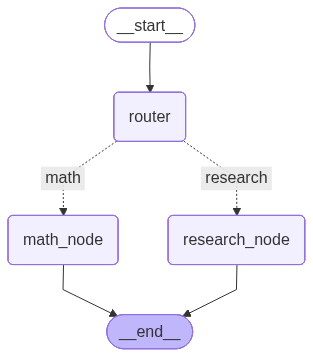

In [17]:
# ==========================================
# Visualize Conditional Workflow
# ==========================================

from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [18]:
# ==========================================
# Understanding Routing
# ==========================================

print("""
Routing Flow

1. User submits a query.

2. Router Node examines the query.

3. Router Node updates:
   state['next_step']

4. Routing Function reads:
   state['next_step']

5. LangGraph selects the next node.

Example:

Query:
'Calculate 125 * 75'

Router Decision:
'math'

Selected Path:
Router -> Math Node


Query:
'What is LangGraph?'

Router Decision:
'research'

Selected Path:
Router -> Research Node
""")


Routing Flow

1. User submits a query.

2. Router Node examines the query.

3. Router Node updates:
   state['next_step']

4. Routing Function reads:
   state['next_step']

5. LangGraph selects the next node.

Example:

Query:
'Calculate 125 * 75'

Router Decision:
'math'

Selected Path:
Router -> Math Node


Query:
'What is LangGraph?'

Router Decision:
'research'

Selected Path:
Router -> Research Node



In [19]:
# ==========================================
# Notebook 4 Recap
# ==========================================

print("""
Key Learnings ->

1. LangGraph supports dynamic routing.
2. Routing decisions are stored in state.
3. Router Nodes decide what should happen next.
4. Routing Functions tell LangGraph
   which path to follow.
5. Different inputs can trigger
   different execution paths.
6. Conditional workflows are the foundation of:
   - Agent Routing
   - Tool Selection
   - Guardrails
   - Supervisor Agents
   - Multi-Agent Systems
7. State drives workflow behavior.
   The graph structure remains the same.
""")


Key Learnings ->

1. LangGraph supports dynamic routing.
2. Routing decisions are stored in state.
3. Router Nodes decide what should happen next.
4. Routing Functions tell LangGraph
   which path to follow.
5. Different inputs can trigger
   different execution paths.
6. Conditional workflows are the foundation of:
   - Agent Routing
   - Tool Selection
   - Guardrails
   - Supervisor Agents
   - Multi-Agent Systems
7. State drives workflow behavior.
   The graph structure remains the same.

